In [3]:
import pandas as pd  # data manipulation
import numpy as np    # numerical computing
import sklearn as sk
import matplotlib.pyplot as plt  # data visualization
import seaborn as sns   # data visualization
import warnings 
warnings.filterwarnings("ignore")

In [4]:
df= pd.read_csv(r"C:\Users\BHAVANASRI\OneDrive\AICW\SelfPracticeSalary_Data.csv")

In [5]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [6]:
df.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [8]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


<Figure size 1200x600 with 0 Axes>

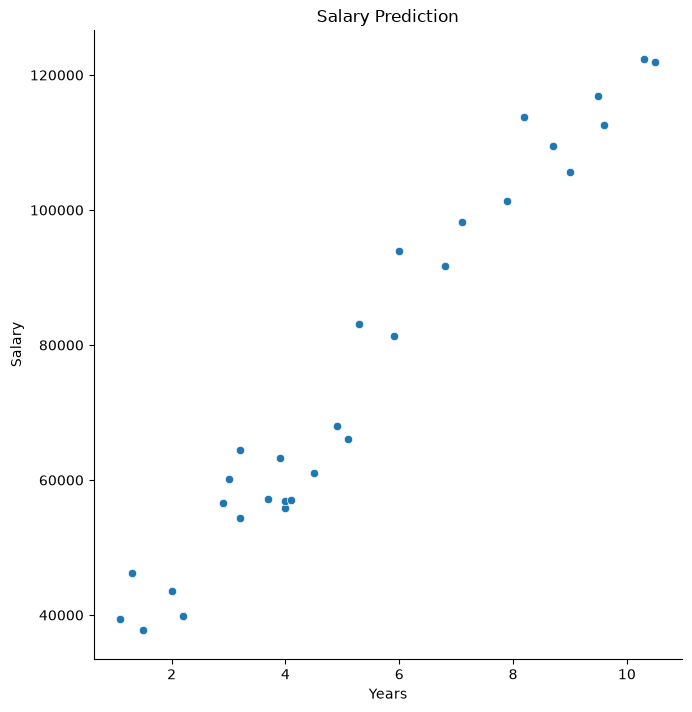

In [9]:
# these plots helps to explain the values and how they are scatter

plt.figure(figsize = (12,6))
sns.pairplot(df,x_vars = ['YearsExperience'],
             y_vars = ['Salary'],size = 7 , kind = 'scatter')

plt.xlabel('Years')
plt.ylabel('Salary')
plt.title('Salary Prediction')
plt.show()

In [10]:
# cooking the data

X = df['YearsExperience']
X.head()

0    1.1
1    1.3
2    1.5
3    2.0
4    2.2
Name: YearsExperience, dtype: float64

In [11]:
Y = df['Salary']
Y.head()

0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
Name: Salary, dtype: float64

In [12]:
# import segregating data from scikit learn 

from sklearn.model_selection import train_test_split

In [13]:
# split the data for train and test 

X_train,X_test,Y_train,Y_test = train_test_split(X,Y, train_size = 0.7 ,random_state = 100)

In [14]:
print(len(X))

30


In [15]:
X_train = X_train.to_numpy()[:,np.newaxis]
X_test = X_test.to_numpy()[:,np.newaxis]

In [16]:
# importing linear regression model from scikit learn 
from sklearn.linear_model import LinearRegression

In [17]:
# Fitting model 

lr = LinearRegression()
lr.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9731.2]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.52e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[11.79]


In [18]:
# predicting the salary for the test value
Y_pred = lr.predict(X_test)

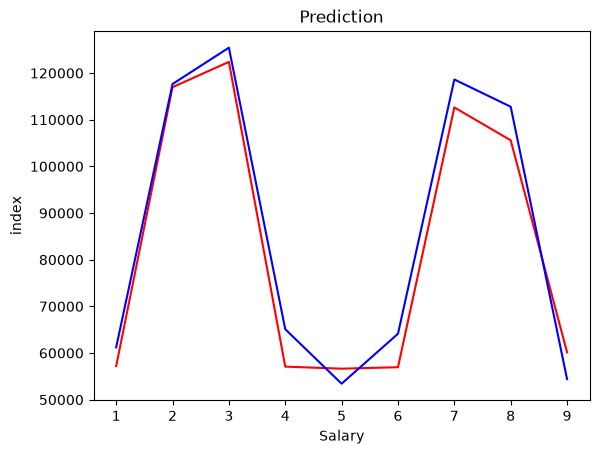

In [19]:
# Plotting the actual and predicted values

c = [i for i in range (1,len(Y_test)+1,1)]
plt.plot(c,Y_test,color='r',linestyle='-')
plt.plot(c,Y_pred,color='b',linestyle='-')
plt.xlabel('Salary')
plt.ylabel('index')
plt.title('Prediction')
plt.show()

In [20]:
from sklearn.metrics import r2_score, mean_squared_error 

In [21]:
# calculate mean square value 
mse = mean_squared_error(Y_test , Y_pred)
mse

30310299.043402553

In [22]:
# CALCULATE R SQUARE VALUE 

rsq = r2_score(Y_test , Y_pred)
mse

30310299.043402553